In [1]:
import napari
from tifffile import imread
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import glob
from scipy.ndimage import binary_fill_holes, distance_transform_edt

In [2]:

def load_images_and_outline(base_dir, t):
    """
    Automatically load DAPI, BF images, and outline for a given tissue ID (e.g., '10_5').
    Works with variable filename prefixes like W1A4, W5A1, etc.

    Parameters:
    - base_dir (str): Base directory
    - t (str): Tissue ID string (e.g., '10_5')

    Returns:
    - img_dapi (ndarray): DAPI image
    - img_bf (ndarray): Brightfield image
    - outline (ndarray): Outline as Nx2 array
    """
    folder = os.path.join(base_dir, t)

    # Use glob to find matching filenames
    dapi_files = glob.glob(os.path.join(folder, "*DAPI.tiff"))
    bf_files = (glob.glob(os.path.join(folder, "*brightfield.tiff")) +
                glob.glob(os.path.join(folder, "*bf.tiff")))
    outline_path = os.path.join(folder, f"sliceVertices{t}.dat")
    mask_files = glob.glob(os.path.join(folder, "*mask.tiff"))

    if not dapi_files:
        raise FileNotFoundError(f"No DAPI image found in {folder}")
    if not bf_files:
        raise FileNotFoundError(f"No BF image found in {folder}")
    if not os.path.exists(outline_path):
        raise FileNotFoundError(f"Outline file not found: {outline_path}")

    # Load the first match for DAPI and BF
    img_dapi = imread(dapi_files[0])
    img_bf = imread(bf_files[0])
    outline = np.loadtxt(outline_path)
    img_mask = imread(mask_files[0]) if mask_files else None

    return img_dapi, img_bf, outline, img_mask


In [ ]:
dir = "D:/Ziwei/Github/STdata/resolve files"
t = "10_5"  # Example tissue ID, adjust as needed

img, img_bf, outline, img_mask = load_images_and_outline(dir, t)

# Animal cap

In [3]:
# (1 micron = 0.1385561 pixels) 1 micron has 7,21729321 pixels
micron_to_pixel = 7.21729321
apical_thickness_um = {
    '10_5': 85.54,
    '12':   43.37,
    '13':   43.33,
    '16':   39.55,
    '18':   32.11,
    '21':   29.29,
    '22':   24.50,
    '24':   22.84,
    '27':   16.55,
}

apical_thickness_px = {
    stage: round(thickness * 7.21729321)
    for stage, thickness in apical_thickness_um.items()
}

In [12]:
dir = "D:/Ziwei/Github/STdata/resolve files"
t = "27"  # Example tissue ID, adjust as needed
img, img_bf, outline, img_mask = load_images_and_outline(dir, t)

outline = np.round(outline).astype(int)
mask_outline = np.zeros_like(img, dtype=bool)

# Outline is (x, y) → (y, x)
yx = np.clip(outline[:, ::-1], [0, 0], np.array(mask_outline.shape) - 1)
mask_outline[yx[:, 0], yx[:, 1]] = 1

filled = binary_fill_holes(mask_outline)

dist_inward = distance_transform_edt(filled)
thickness_px = int(round(apical_thickness_um[t] * micron_to_pixel))

# Apical mask = pixels within thickness_px from the edge
apical_mask = dist_inward <= thickness_px


In [13]:
viwer = napari.Viewer()
viwer.add_image(img, name='DAPI', colormap='gray', contrast_limits=[img.min(), img.max()])
viwer.add_labels(img_mask, name='cellpose_seg', opacity=0.5)
viwer.add_labels(mask_outline, name='Outline', opacity=0.5)
viwer.add_labels(apical_mask, name='Apical_layers', opacity=0.5)

<Labels layer 'Apical_layers' at 0x1214439f760>

# fill the black chunck

In [32]:
label = imread(os.path.join(dir, t, "outline_label.tif"))

In [ ]:

outline = np.round(outline).astype(int)
mask = np.zeros_like(img, dtype=bool)

# Clip and convert (x, y) → (y, x)
yx = np.clip(outline[:, ::-1], [0, 0], np.array(mask.shape) - 1)
mask[yx[:, 0], yx[:, 1]] = 1

# Fill the inside of the outline
filled_mask = binary_fill_holes(mask)

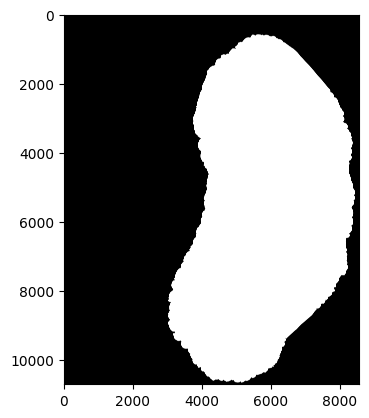

In [41]:
plt.imshow(filled_mask, cmap='gray')

In [54]:
df = pd.read_csv(os.path.join(dir, t, "MC1_27032024_W4A3_scored_Results.txt"), sep="\t", header=None)
df.columns = ['x', 'y', 'z', 'gene', 'score']
sample = df.sample(50, random_state=42).copy()

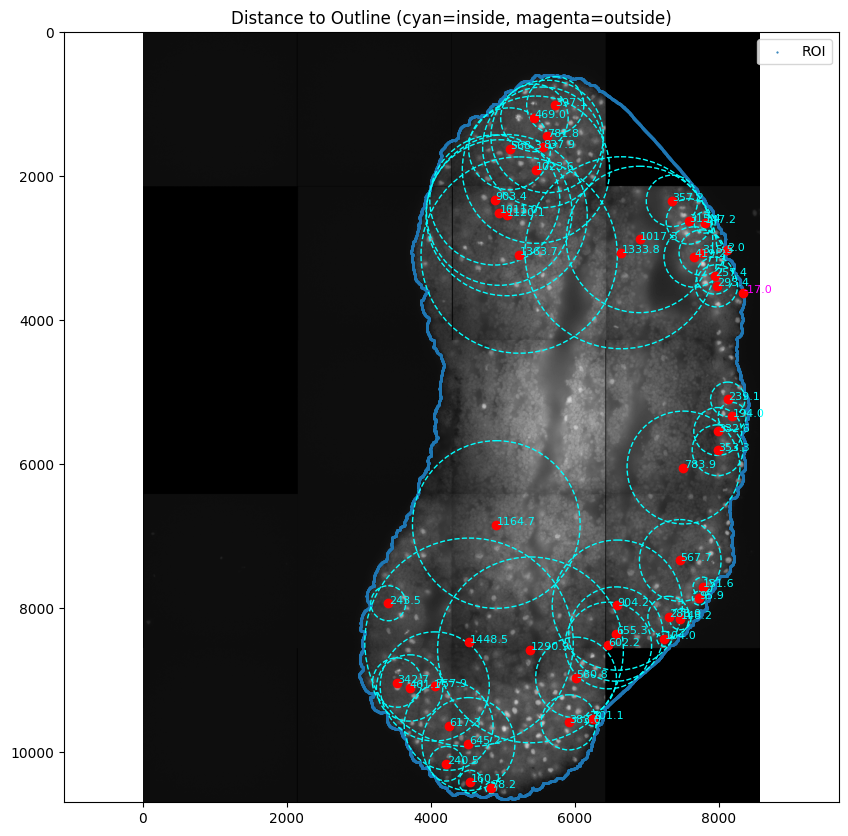

In [55]:
from scipy.spatial import KDTree
coords = sample[['x', 'y']].values
coords_int = np.round(coords).astype(int)
coords_int[:, 0] = np.clip(coords_int[:, 0], 0, img.shape[1] - 1)
coords_int[:, 1] = np.clip(coords_int[:, 1], 0, img.shape[0] - 1)
inside_mask = filled_mask[coords_int[:, 1], coords_int[:, 0]]

# --- Compute signed distances ---
tree = KDTree(outline)
distances, _ = tree.query(coords)
signed_distances = np.where(inside_mask, distances, -distances)
sample['Distance_To_Outline'] = signed_distances

# --- Plot result ---
plt.figure(figsize=(20, 20))
plt.imshow(img, cmap='gray', origin='upper')
plt.scatter(outline[:, 0], outline[:, 1], s=0.3, label='ROI')

for _, row in sample.iterrows():
    x, y, d = row['x'], row['y'], row['Distance_To_Outline']
    color = 'cyan' if d > 0 else 'magenta'
    plt.plot(x, y, 'ro')
    plt.gca().add_patch(plt.Circle((x, y), abs(d), edgecolor=color, facecolor='none', linestyle='--'))
    plt.text(x + 5, y + 5, f"{d:.1f}", color=color, fontsize=8)

plt.title("Distance to Outline (cyan=inside, magenta=outside)")
plt.axis('equal')
plt.legend()
plt.show()

In [27]:
print("DAPI shape:", img.shape)
print("BF shape:", img_bf.shape)


DAPI shape: (8564, 8562)
BF shape: (8564, 8562)


In [28]:
mask = np.zeros_like(img, dtype=np.uint8)

# Step 2: Convert outline to integer pixel indices (y, x order for image)
outline = np.round(outline).astype(int)
xy = np.clip(outline, 0, np.array(mask.shape[::-1]) - 1)  # clip to stay within bounds
yx = xy[:, ::-1]  # convert (x, y) → (y, x)

# Step 3: Set outline pixels to 1
mask[yx[:, 0], yx[:, 1]] = 1

In [29]:
viewer = napari.Viewer()
viewer.add_image(img,contrast_limits=(img.min(),img.max()), name='DAPI')
viewer.add_image(img_bf, contrast_limits=(img_bf.min(), img_bf.max()), name='Brightfield')
# Reverse to (y, x) order
outline_yx = outline[:, ::-1]
# Convert outline to label for annotations
viewer.add_labels(mask, name='outline_label')

<Labels layer 'outline_label' at 0x1868cdeadc0>

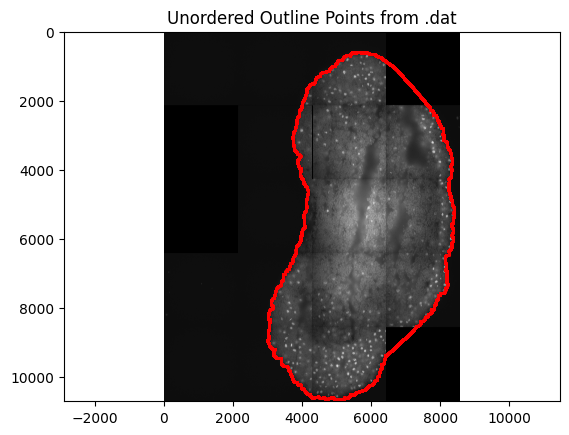

In [ ]:
plt.imshow(img, cmap='gray')
plt.plot(outline[:, 0], outline[:, 1], s=1, c='red')  # Don't use plt.plot()
plt.title("Unordered Outline Points from .dat")
plt.axis('equal')
plt.show()

Found label for time frame '10_5' — converting to .dat


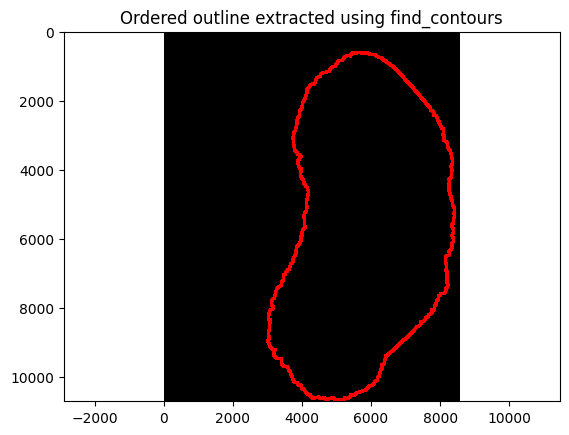

No label found for '12'
Found label for time frame '13' — converting to .dat


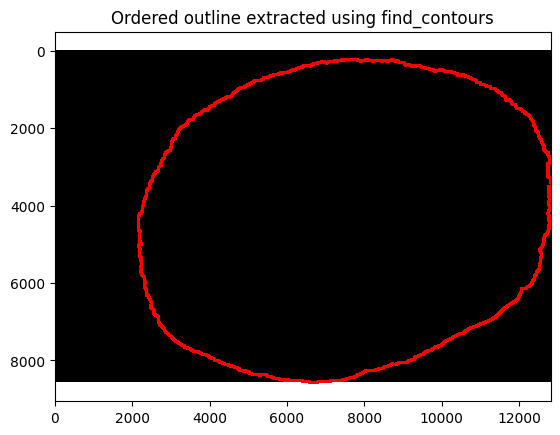

No label found for '16'
No label found for '18'
No label found for '21'
No label found for '22'
No label found for '24'
Found label for time frame '27' — converting to .dat


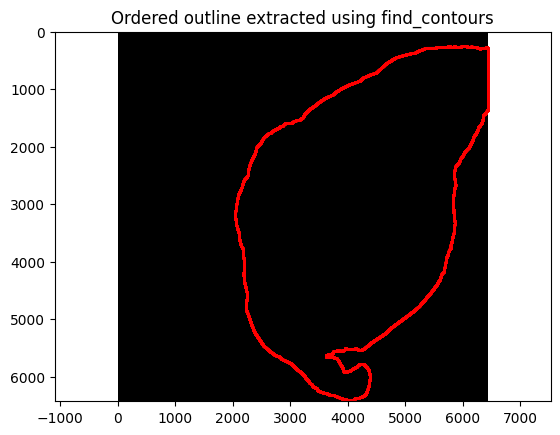

No label found for '8'


In [ ]:
import os
import numpy as np
from tifffile import imread

def convert_label_tifs_to_dat(base_dir):
    for t in os.listdir(base_dir):
        folder = os.path.join(base_dir, t)
        if not os.path.isdir(folder):
            continue

        label_path = os.path.join(folder, "outline_label.tif")
        dat_path = os.path.join(folder, f"sliceVertices{t}.dat")

        if os.path.exists(label_path):
            print(f"Found label for time frame '{t}' — converting to .dat")
            
            # Load label image
            label_img = imread(label_path)

            # Extract (x, y) pixel coordinates where label == 1
            y, x = np.where(label_img == 1)
            coords_xy = np.stack([x, y], axis=1).astype(float)

            # Save as .dat
            np.savetxt(dat_path, coords_xy, fmt="%.1f")
            
            plt.scatter(coords_xy[:, 0], coords_xy[:, 1], s=1, c='red')
            plt.title('Ordered outline extracted using find_contours')
            plt.axis('equal')
            plt.show()
        else:
            print(f"No label found for '{t}'")

# Example usage
convert_label_tifs_to_dat(dir)  # <-- replace with your actual base directory
